In [1]:
import pandas as pd
from src.calculators import IPPCalculator, IRDCalculator
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Carregar dados dos parlamentares

In [2]:
df_parls_raw = pd.read_csv(
    "./data/df_parlamentares_por_legislatura.csv", 
)

legislaturas = df_parls_raw["idLegislatura"].unique()

# IRD
df_for_equality = pd.read_csv('./outputs/df_for_ird.csv')
df_for_equality.set_index(["id", "idLegislatura"], inplace=True)

# IPP data
df = pd.read_excel("./outputs/df_ipp_v2f.xlsx")
df.set_index(["id", "idLegislatura"], inplace=True)


# Calculate indexes

## Calcular IPP

In [3]:
# Calculate IPP
ipp_calculator = IPPCalculator()
df_with_ipp = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df.loc[pd.IndexSlice[:, legislatura], :]
    df_calc = ipp_calculator.calculate(df_legislatura)
    df_with_ipp = pd.concat([df_with_ipp, df_calc])

### Gráficos

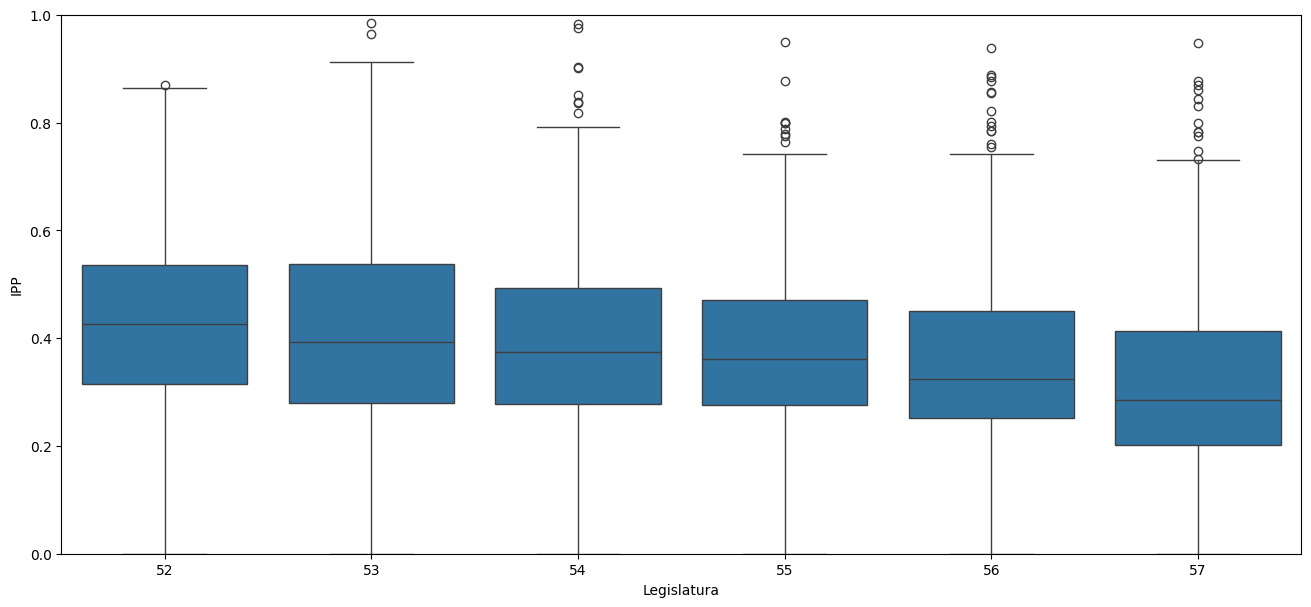

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

legislaturas = [ l for l in df_with_ipp.reset_index()['idLegislatura'].unique() if l > 51]
df_ipp = df_with_ipp.loc[pd.IndexSlice[:, legislaturas], :]

sns.boxplot(x='idLegislatura', y='ipp', data=df_ipp.reset_index())

plt.gcf().set_size_inches(16, 7)

plt.ylim(0, 1)

plt.ylabel("IPP")
plt.xlabel("Legislatura")

plt.savefig("docs/figures/ipp_boxplot.png", dpi=300)
plt.show()

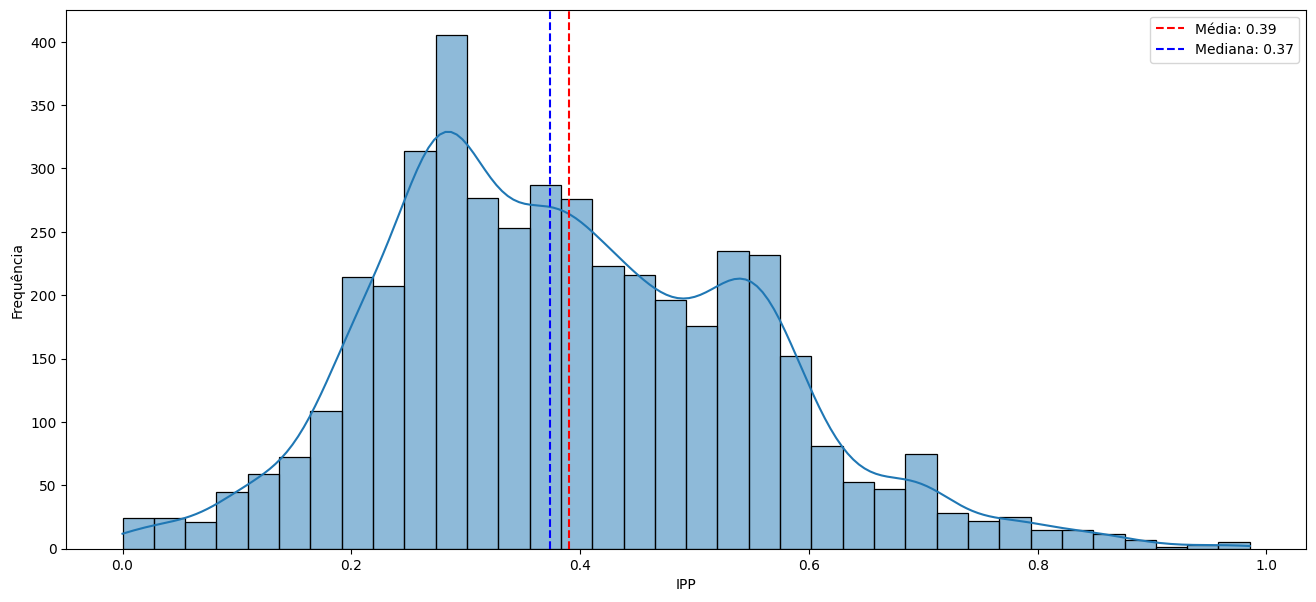

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_with_ipp.reset_index()['ipp'], kde=True)

mean_ipp = df_with_ipp.reset_index()['ipp'].mean()
median_ipp = df_with_ipp.reset_index()['ipp'].median()

plt.axvline(mean_ipp, color='red', linestyle='--', label=f'Média: {mean_ipp:.2f}')
plt.axvline(median_ipp, color='blue', linestyle='--', label=f'Mediana: {median_ipp:.2f}')

plt.legend()

plt.gcf().set_size_inches(16, 7)

plt.ylabel("Frequência")
plt.xlabel("IPP")

plt.savefig("docs/figures/ipp_histplot.png", dpi=300)

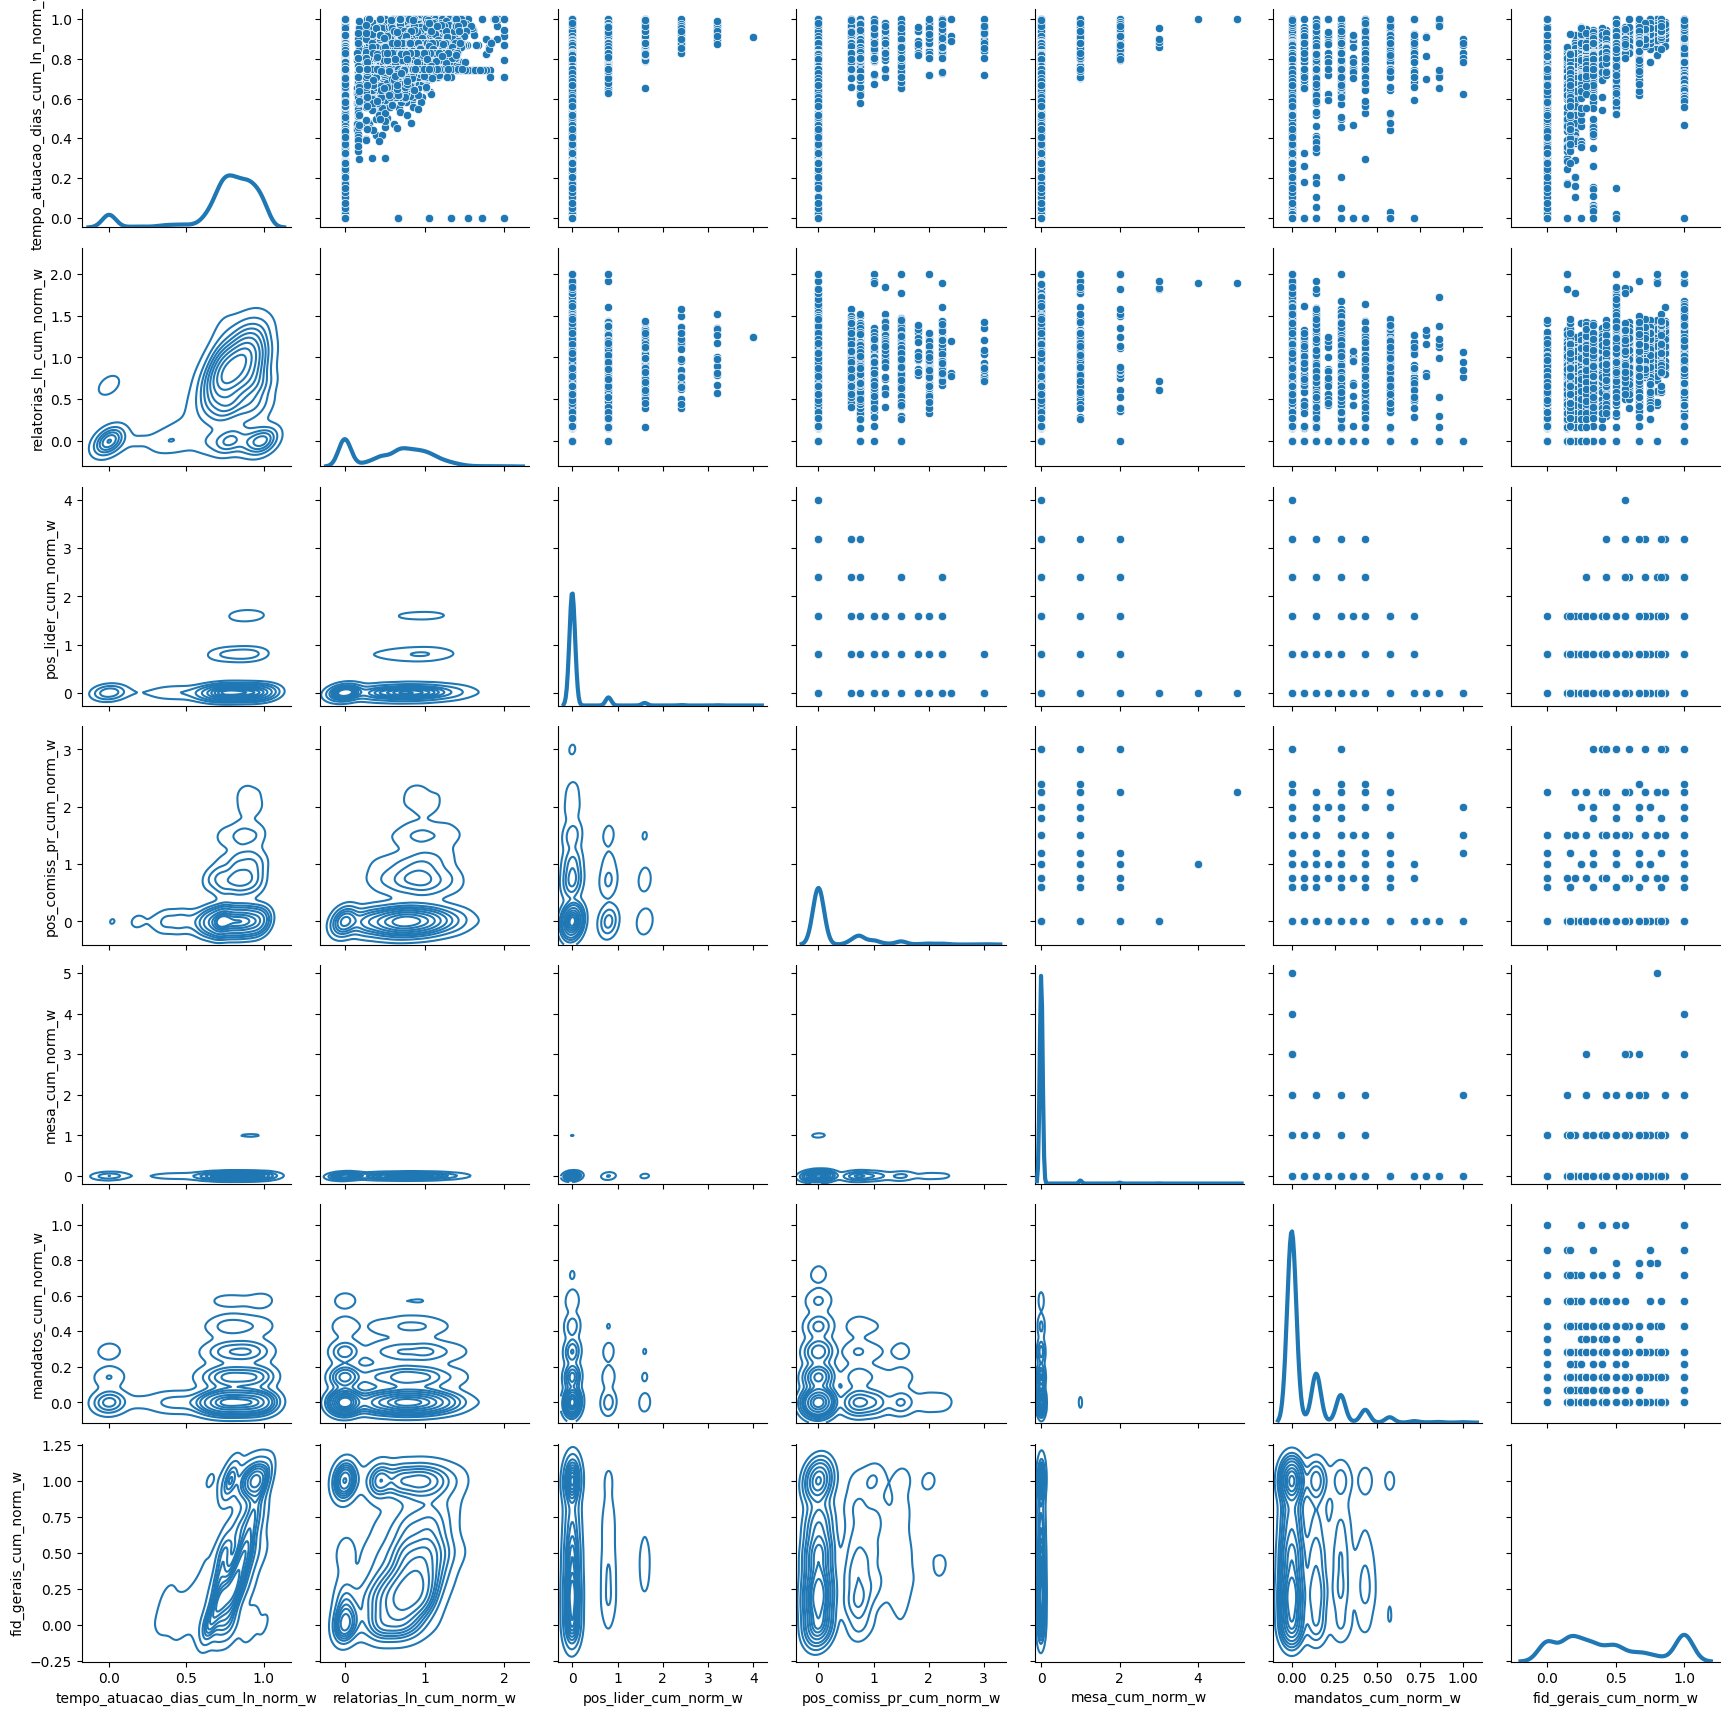

In [6]:
vars = [c for c in df_with_ipp.columns if "cum" in c and "norm" in c and "w" in c] 

g = sns.PairGrid(df_with_ipp[vars])
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)


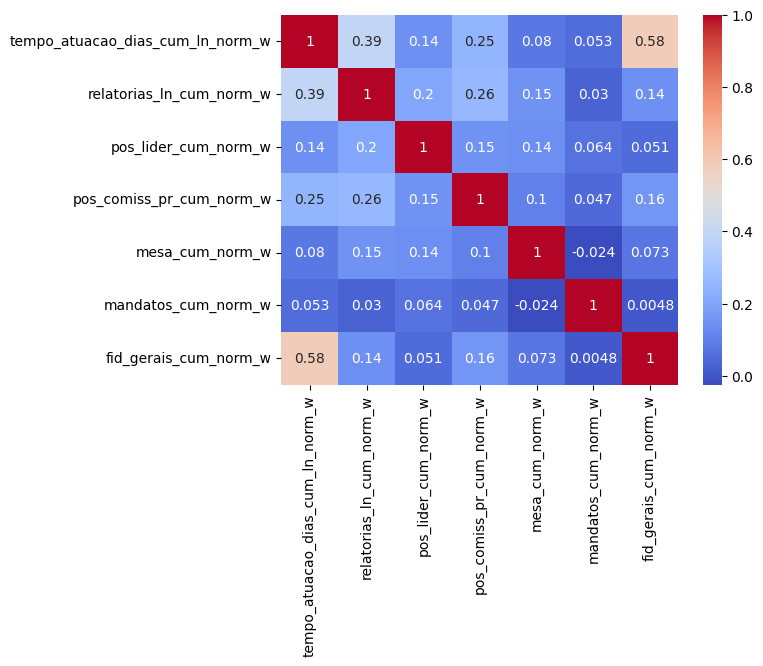

In [7]:


sns.heatmap(df_with_ipp[vars].corr(), annot=True, cmap="coolwarm")
plt.show()

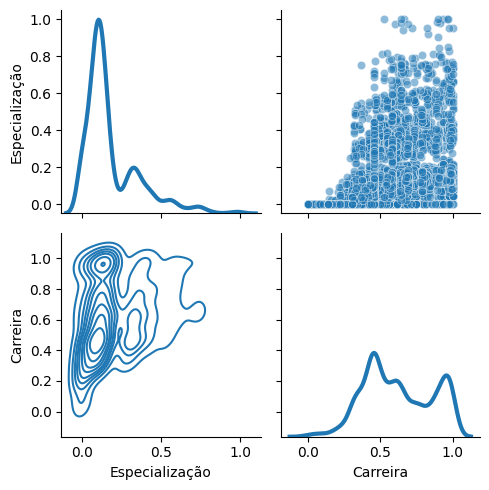

In [8]:
df_pairplot = df_with_ipp[
    ["dim_comprometimento_norm", "dim_carreira_norm"]
].reset_index(drop=True)
df_pairplot.rename(
    columns={
        "dim_comprometimento_norm": "Especialização",
        "dim_carreira_norm": "Carreira",
    },
    inplace=True,
)
g = sns.PairGrid(df_pairplot)
g.map_upper(sns.scatterplot, alpha=0.5)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

plt.tight_layout()
plt.savefig("docs/figures/ipp_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
df_with_ipp[['dim_comprometimento_norm', 'dim_carreira_norm']].corr()

,dim_comprometimento_norm,dim_carreira_norm
dim_comprometimento_norm,1.000000,0.318914
dim_carreira_norm,0.318914,1.000000


## Calcular Equality index

In [10]:
df_for_equality.describe()

,F,M,branca,n_branca
count,6250.000000,6250.000000,6250.000000,6250.000000
mean,0.090880,0.909120,0.510240,0.150400
std,0.287461,0.287461,0.499935,0.357492
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


In [11]:
population_proportions = {
    "F": 0.52,
    "M": 0.48,
    "branca": 0.2,
    "n_branca": 0.8,
}


aggeregated_index = []
df_with_equality = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df_for_equality.loc[pd.IndexSlice[:, legislatura], :]

    # Calculate equality index
    calculator = IRDCalculator()
    df_calc = calculator.calculate(
        df_legislatura,
        population_proportions,
    )

    df_with_equality = pd.concat([df_with_equality, df_calc])

    aggeregated_index.append(
        {
            "legislatura": legislatura,
            "normalized_index": calculator.normalized_index,
        }
    )


# Print adjustment index
print(f"Overall Normalized Equality Index: {calculator.normalized_index:.4f}")

# Analyze weights distribution
print("\nWeight Distribution Summary:")
print(df_with_equality[["equality_weight", "equality_weight_normalized"]].describe())

Overall Normalized Equality Index: 0.6933

Weight Distribution Summary:
       equality_weight  equality_weight_normalized
count      3764.000000                 3764.000000
mean          0.500000                    0.001594
std           0.517827                    0.001319
min           0.130685                    0.000822
25%           0.202416                    0.000913
50%           0.215035                    0.001026
75%           0.854945                    0.002221
max           3.055476                    0.015933


In [12]:
df = pd.DataFrame(sorted(aggeregated_index, key=lambda x: x["legislatura"]))

### Evolução temporal do índice agregado

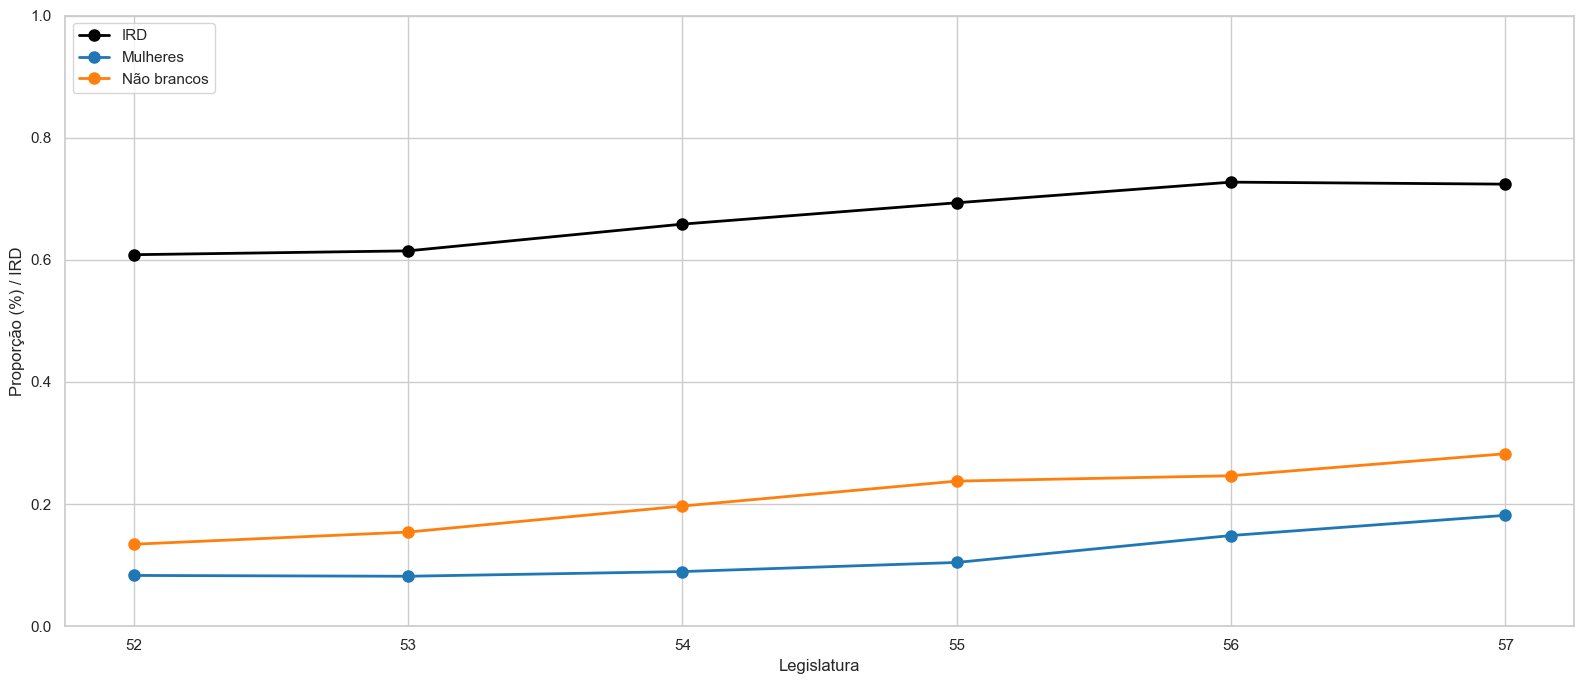

In [13]:
df_g = df_for_equality.groupby('idLegislatura').mean(numeric_only=True).copy()
df_g.reset_index(inplace=True)


df_g = df_g.merge(df, left_on='idLegislatura', right_on='legislatura', how='left')
df_g = df_g[~df_g['legislatura'].isna()]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 7))
ax = plt.gca()

x = np.arange(len(df_g['idLegislatura']))

# Linha do IRD
ax.plot(
    x,
    df_g['normalized_index'],
    color='black',
    marker='o',
    label='IRD',
    linewidth=2,
    markersize=8
)
# Linhas para cada grupo
ax.plot(
    x,
    df_g['F'],
    color='tab:blue',
    marker='o',
    label='Mulheres',
    linewidth=2,
    markersize=8
)
ax.plot(
    x,
    df_g['n_branca'],
    color='tab:orange',
    marker='o',
    label='Não brancos',
    linewidth=2,
    markersize=8
) 


ax.set_ylabel("Proporção (%) / IRD")
ax.set_ylim(0, 1)
ax.set_xlabel("Legislatura")
ax.set_xticks(x)
ax.set_xticklabels(df_g['idLegislatura'].astype(str), rotation=0)

# Legenda única
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left')

plt.tight_layout()
plt.savefig("docs/figures/ird_vs_time.png", dpi=300, bbox_inches='tight')
plt.show()

### Distribuição do índice no npivel individual

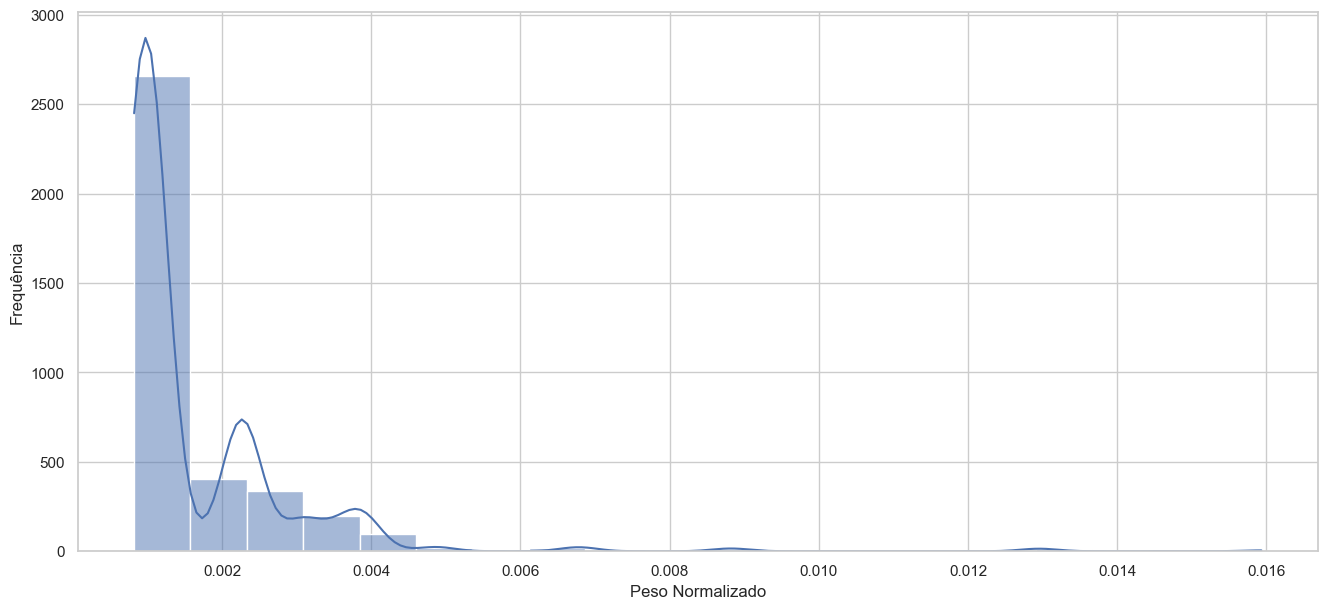

In [14]:
# boxplost of the sdistribution of each idLegislatura for the equality_index_normalized
sns.histplot(df_with_equality['equality_weight_normalized'], bins=20, kde=True)

plt.gcf().set_size_inches(16, 7)

plt.ylabel("Frequência")
plt.xlabel("Peso Normalizado")

plt.savefig("docs/figures/ird_distribution.png", dpi=300)
plt.show()

# Join


In [15]:
df_joined = df_with_ipp.join(df_with_equality)

<Axes: xlabel='equality_weight_normalized', ylabel='ipp'>

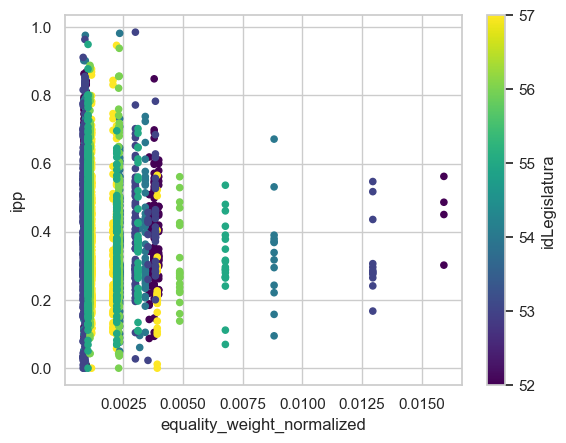

In [16]:
# df_joined.loc[pd.IndexSlice[:, 57], :].reset_index().plot.scatter(
#     x="equality_weight", y="ipp", c="idLegislatura", cmap="viridis"
# )
df_joined.reset_index().plot.scatter(
    x="equality_weight_normalized", y="ipp", c="idLegislatura", cmap="viridis"
)

## Add Cohesion INdex

In [17]:
def treat_name(name: str):
    return (
        str(name)
        .replace(".", "")
        .replace(" ", "")
        .replace("-", "")
        .replace("'", "")
        .replace("  ", " ")
        .lower()
    )

In [18]:
df_cohesion = pd.read_csv("./src/indices/indice_coesao_interna_perfil.csv")

df_cohesion["idLegislatura"] = 56
df_cohesion["name_treated"] = df_cohesion["Profile"].apply(treat_name)

FileNotFoundError: [Errno 2] No such file or directory: './src/indices/indice_coesao_interna_perfil.csv'

In [ ]:
df_to_merge = df_joined.reset_index()
df_to_merge["name_treated"] = df_to_merge["ultimoStatus.nome"].apply(treat_name)

In [ ]:
df_m = df_to_merge.merge(
    df_cohesion,
    left_on=["name_treated", "idLegislatura"],
    right_on=["name_treated", "idLegislatura"],
    how="left",
)
df_m.head()

,id,idLegislatura,Unnamed: 0,ultimoStatus.nome,ultimoStatus.siglaPartido,sexo,dataNascimento,escolaridade,idade_posse,tempo_atuacao_dias_cum_ln,...,equality_index_normalized,name_treated,Profile,Mean_Cosine,Median_Cosine,Partido,Estado,total_posts_profile_antes_filtro,total_posts_profile_depois_filtro,num_publicacoes_neste_df
0,62926,52,60,PASTOR REINALDO,PTB,M,1949-02-14,Superior Incompleto,53,7.286876,...,0.489235,pastorreinaldo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,64224,52,61,ROBÉRIO NUNES,PFL,M,1964-11-03,Superior,38,7.286876,...,0.489235,robérionunes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,64960,52,62,MARIA HELENA,MDB,F,1949-06-15,Superior,53,7.286876,...,0.489235,mariahelena,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,65511,52,82,MIGUEL ARRAES,PSB,M,1916-12-15,Superior,74,7.767264,...,0.489235,miguelarraes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65551,52,85,WAGNER LAGO,PDT,M,1944-02-15,Superior,42,7.956477,...,0.489235,wagnerlago,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Mean_Cosine', ylabel='ipp'>

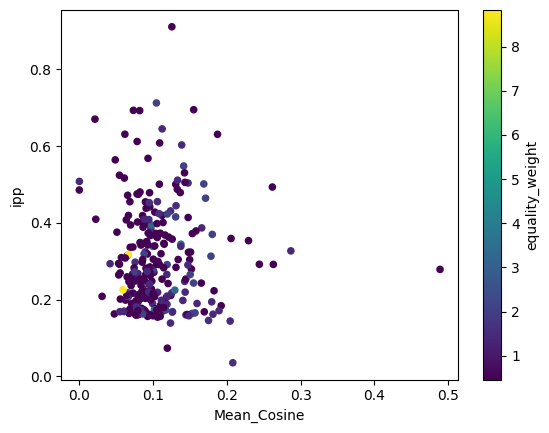

In [ ]:
df_m.plot.scatter(x="Mean_Cosine", y="ipp", c="equality_weight", cmap="viridis")

# Calculate Quality Index

In [ ]:
index_dimensions = [
    'equality_weight_normalized',
    'ipp',
    'Median_Cosine',
]
df_m['quality_index'] = df_m[index_dimensions].mean(axis=1)
df_m[['quality_index', *index_dimensions]].describe()

,quality_index,equality_weight_normalized,ipp,Median_Cosine
count,6250.000000,6250.000000,3764.000000,269.000000
mean,0.415877,0.478112,0.292040,0.007493
std,0.138618,0.168832,0.136539,0.041998
min,0.151642,0.345503,0.000000,-0.000068
25%,0.338685,0.379595,0.195398,-0.000005
50%,0.405174,0.407404,0.271698,0.000038
75%,0.442544,0.483443,0.369342,0.000427
max,0.999985,1.000000,0.910966,0.547412


In [ ]:
df_m.to_excel("./outputs/df_m_v1.xlsx")